## **Bank Churn EDA**

## **Import Libraries**

In [ ]:
!pip install ydata-profiling

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ydata_profiling import ProfileReport

In [ ]:
df = pd.read_csv("Capstone_Bank Churn Data.csv")

In [ ]:
# visual look at the data
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [ ]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [ ]:
df.sample(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
3292,3293,15757632,Hughes-Jones,496,France,Female,41,1,176024.05,2,1,0,182337.98,0
9910,9911,15784042,L?,624,France,Male,55,7,118793.60,1,1,1,95022.02,1
8151,8152,15750970,Davidson,500,Spain,Male,40,1,99004.24,1,1,1,152845.99,0
9313,9314,15757912,Bradley,722,Germany,Female,37,0,125977.81,1,0,0,160162.42,0
1908,1909,15626983,Ledford,605,Spain,Female,48,6,0.00,2,1,1,40062.99,0
6218,6219,15667462,Duncan,707,Spain,Male,43,10,0.00,2,1,0,118368.20,0
9114,9115,15605737,George,541,France,Male,36,5,0.00,2,1,0,124795.84,0
205,206,15773039,Ku,550,France,Male,37,3,0.00,1,1,1,179670.31,0
2777,2778,15776233,Kruglova,758,Germany,Female,61,8,125397.21,1,1,0,182184.09,1
9161,9162,15750049,Steele,621,France,Male,40,10,163823.37,1,0,0,89519.47,0


In [ ]:
df["Geography"].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

## **Data Dictionary**

 data dictionary for the dataset:  

| Column Name         | Data Type | Description |
|---------------------|-----------|-------------|
| **RowNumber**       | Integer   | Unique index for each row in the dataset. |
| **CustomerId**      | Integer   | Unique identifier assigned to each customer. |
| **Surname**         | String    | Last name of the customer. |
| **CreditScore**     | Integer   | Customer's credit score, which may impact their likelihood of exiting. |
| **Geography**       | String    | Country where the customer resides (France, Spain, Germany). |
| **Gender**         | String    | Customer's gender (Male/Female). |
| **Age**            | Integer   | Age of the customer. |
| **Tenure**         | Integer   | Number of years the customer has been with the bank. |
| **Balance**        | Float     | Account balance of the customer. |
| **NumOfProducts**  | Integer   | Number of financial products the customer holds with the bank. |
| **HasCrCard**      | Integer   | Indicates whether the customer has a credit card (1 = Yes, 0 = No). |
| **IsActiveMember** | Integer   | Indicates whether the customer is an active bank member (1 = Yes, 0 = No). |
| **EstimatedSalary**| Float     | Estimated annual salary of the customer. |
| **Exited**         | Integer   | Indicates whether the customer has left the bank (1 = Yes, 0 = No). |


## **Customer Churn Analysis**
- What is the overall churn rate (percentage of customers who exited the bank)?
- How does churn vary by Geography (France, Spain, Germany)?
- Does Age influence churn? Are older customers more likely to leave?
- Is there a relationship between CreditScore and customer churn?
- How does Tenure impact customer churn? Do long-term customers leave less frequently?
- Do customers with higher Balance churn less?
- Are customers with more Products (NumOfProducts) more likely to stay?
- Does having a Credit Card impact churn? (HasCrCard)
- Are Active Members (IsActiveMember = 1) less likely to churn?
- Is there a correlation between EstimatedSalary and churn?

In [ ]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df["Gender"].unique()

array(['Female', 'Male'], dtype=object)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [ ]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


<ipython-input-13-920ded6e5a62>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Exited", palette= 'coolwarm')


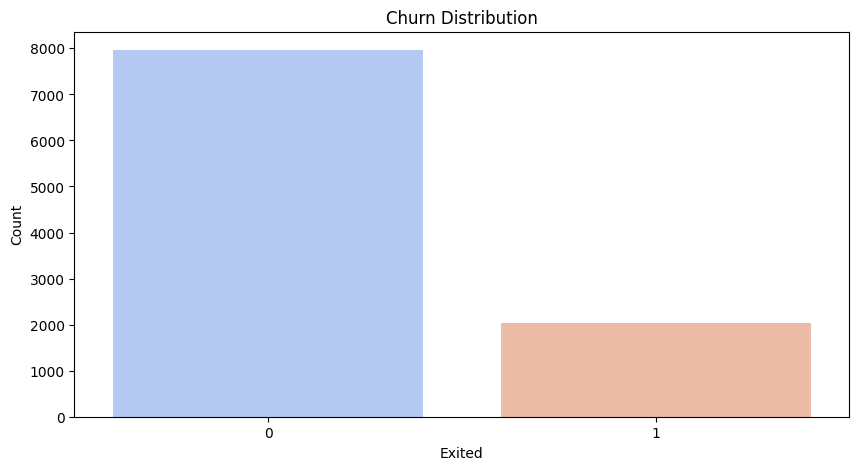

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Exited", palette= 'coolwarm')
plt.title("Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Count")
plt.show();

In [ ]:
import random as rn
us_states = [
    'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware',
    'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky',
    'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi',
    'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico',
    'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
    'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont',
    'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming'
]

df["state"] = [rn.choice(us_states) for i in range(len(df))]

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,state
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Virginia
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Texas
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Delaware
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Washington
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Wisconsin


In [ ]:
df = df.drop(columns = ["Geography", "RowNumber"])

In [ ]:
df.shape

(10000, 13)

In [ ]:
df.columns = df.columns.str.lower()

In [ ]:
df.head()

,customerid,surname,creditscore,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,state
0,15634602,Hargrave,619,Female,42,2,0.00,1,1,1,101348.88,1,Virginia
1,15647311,Hill,608,Female,41,1,83807.86,1,0,1,112542.58,0,Texas
2,15619304,Onio,502,Female,42,8,159660.80,3,1,0,113931.57,1,Delaware
3,15701354,Boni,699,Female,39,1,0.00,2,0,0,93826.63,0,Washington
4,15737888,Mitchell,850,Female,43,2,125510.82,1,1,1,79084.10,0,Wisconsin


In [ ]:
df["age"].unique()

array([42, 41, 39, 43, 44, 50, 29, 27, 31, 24, 34, 25, 35, 45, 58, 32, 38,
       46, 36, 33, 40, 51, 61, 49, 37, 19, 66, 56, 26, 21, 55, 75, 22, 30,
       28, 65, 48, 52, 57, 73, 47, 54, 72, 20, 67, 79, 62, 53, 80, 59, 68,
       23, 60, 70, 63, 64, 18, 82, 69, 74, 71, 76, 77, 88, 85, 84, 78, 81,
       92, 83])

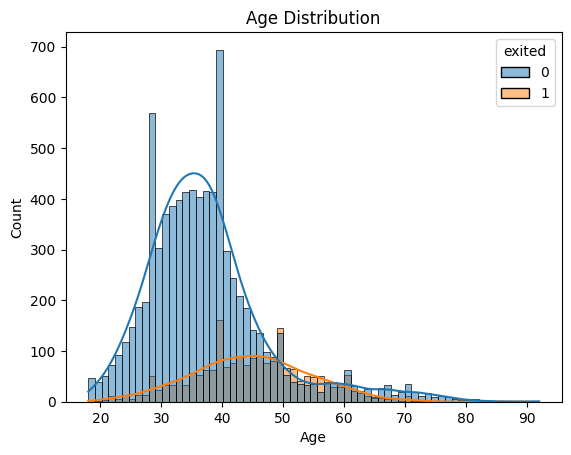

In [ ]:
sns.histplot(data=df, x="age", kde=True, hue= "exited")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show();

In [ ]:
bins = [0, 15, 25, 35, 45, 55, 65, 100]
labels = ['0-14', '15-24', '25-34', '35-44', '45-54', '55-64', '65+']

df["age_group"] = df["age"].apply(lambda x: pd.cut([x], bins=bins, labels=labels)[0])
df.head()

,customerid,surname,creditscore,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,state,age_group
0,15634602,Hargrave,619,Female,42,2,0.00,1,1,1,101348.88,1,Virginia,35-44
1,15647311,Hill,608,Female,41,1,83807.86,1,0,1,112542.58,0,Texas,35-44
2,15619304,Onio,502,Female,42,8,159660.80,3,1,0,113931.57,1,Delaware,35-44
3,15701354,Boni,699,Female,39,1,0.00,2,0,0,93826.63,0,Washington,35-44
4,15737888,Mitchell,850,Female,43,2,125510.82,1,1,1,79084.10,0,Wisconsin,35-44


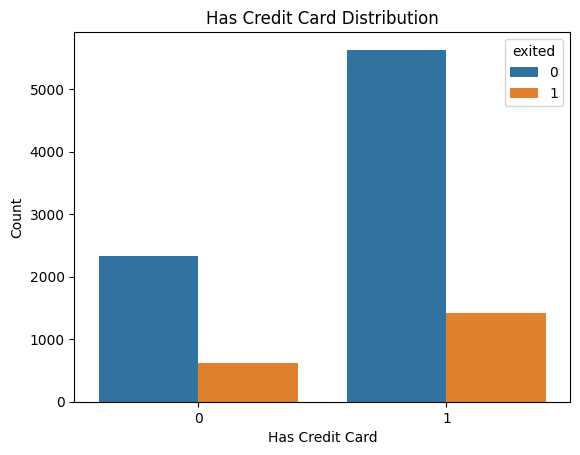

In [ ]:
sns.countplot(data = df, x = "hascrcard", hue = "exited")
plt.title("Has Credit Card Distribution")
plt.xlabel("Has Credit Card")
plt.ylabel("Count")
plt.show();

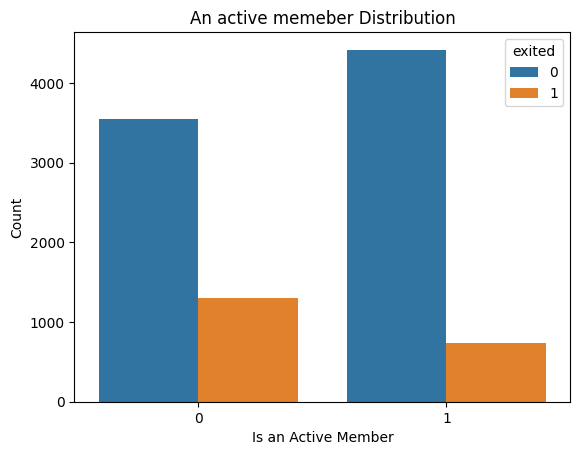

In [ ]:
sns.countplot(data = df, x = "isactivemember", hue = "exited")
plt.title("An active memeber Distribution")
plt.xlabel("Is an Active Member")
plt.ylabel("Count")
plt.show();

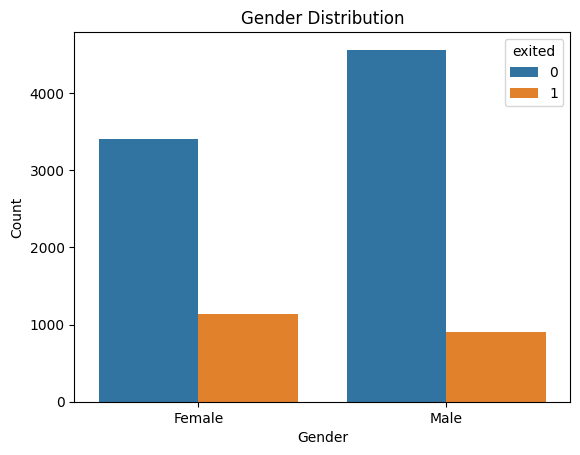

In [ ]:
sns.countplot(data = df, x = "gender", hue = "exited")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show();

In [ ]:
age_labels = ['0-14', '15-24', '25-34', '35-44', '45-54', '55-64', '65+']

Text(0, 0.5, 'Count')

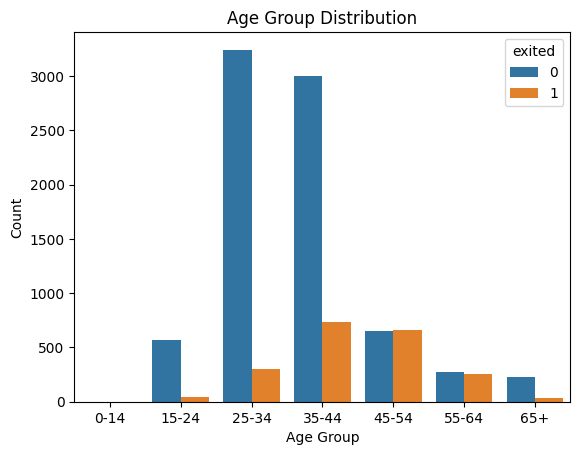

In [ ]:
sns.countplot(data = df, x = "age_group", hue = "exited", order = age_labels)
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")

**Notes**
A bulk of customers who churn are between the ages of 35-54

Text(0, 0.5, 'Estimated Salary')

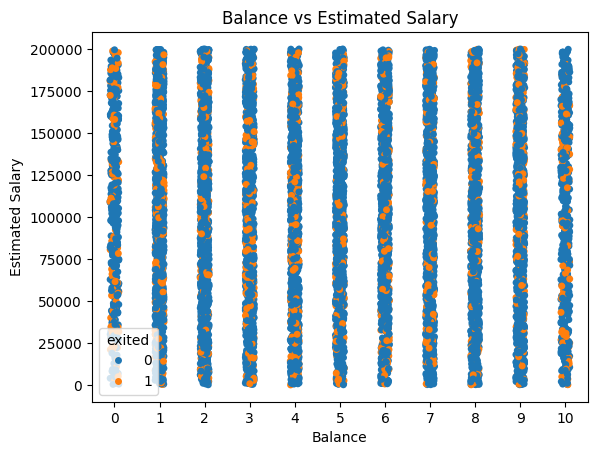

In [ ]:
sns.stripplot(data = df, x = "tenure", y = "estimatedsalary", hue = "exited")
plt.title("Balance vs Estimated Salary")
plt.xlabel("Balance")
plt.ylabel("Estimated Salary")

Text(0, 0.5, 'Count')

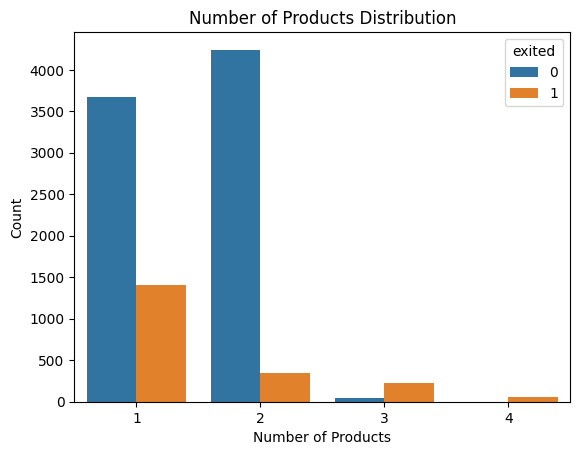

In [ ]:
sns.countplot(data = df, x = "numofproducts", hue = "exited")
plt.title("Number of Products Distribution")
plt.xlabel("Number of Products")
plt.ylabel("Count")

**Notes**
- It can be seen That Customers subscribed to 3 products have an unsusual propensity to churn.
- Customers signed up to 1 products also have high churn rate, this could be linked to the likelyhood of new customers to be signed up on 1 product.

In [ ]:
#df.to_csv("cleaned_data.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerid       10000 non-null  int64  
 1   surname          10000 non-null  object 
 2   creditscore      10000 non-null  int64  
 3   gender           10000 non-null  object 
 4   age              10000 non-null  int64  
 5   tenure           10000 non-null  int64  
 6   balance          10000 non-null  float64
 7   numofproducts    10000 non-null  int64  
 8   hascrcard        10000 non-null  int64  
 9   isactivemember   10000 non-null  int64  
 10  estimatedsalary  10000 non-null  float64
 11  exited           10000 non-null  int64  
 12  state            10000 non-null  object 
 13  age_group        10000 non-null  object 
dtypes: float64(2), int64(8), object(4)
memory usage: 1.1+ MB


In [ ]:
df["tenure"].unique()

array([ 2,  1,  8,  7,  4,  6,  3, 10,  5,  9,  0])

In [ ]:
group = [
    "Newcomers",
    "Early Career",
    "Mid Career",
    "Experienced",
    "Advanced Experience",
    "Veteran"
]

# Define tenure group mapping function
def categorize_tenure(tenure):
    if tenure == 0:
        return group[0]  # Newcomers
    elif 1 <= tenure <= 3:
        return group[1]  # Early Career
    elif 4 <= tenure <= 5:
        return group[2]  # Mid Career
    elif 6 <= tenure <= 7:
        return group[3]  # Experienced
    elif 8 <= tenure <= 9:
        return group[4]  # Advanced Experience
    else:
        return group[5]  # Veteran

# Apply function to create tenure_group column
df["tenure_group"] = df["tenure"].apply(categorize_tenure)

In [ ]:
df.head()

,customerid,surname,creditscore,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,state,age_group,tenure_group
0,15634602,Hargrave,619,Female,42,2,0.00,1,1,1,101348.88,1,Virginia,35-44,Early Career
1,15647311,Hill,608,Female,41,1,83807.86,1,0,1,112542.58,0,Texas,35-44,Early Career
2,15619304,Onio,502,Female,42,8,159660.80,3,1,0,113931.57,1,Delaware,35-44,Advanced Experience
3,15701354,Boni,699,Female,39,1,0.00,2,0,0,93826.63,0,Washington,35-44,Early Career
4,15737888,Mitchell,850,Female,43,2,125510.82,1,1,1,79084.10,0,Wisconsin,35-44,Early Career


In [ ]:
sorted(df["creditscore"].unique())

[np.int64(350),
 np.int64(351),
 np.int64(358),
 np.int64(359),
 np.int64(363),
 np.int64(365),
 np.int64(367),
 np.int64(373),
 np.int64(376),
 np.int64(382),
 np.int64(383),
 np.int64(386),
 np.int64(395),
 np.int64(399),
 np.int64(401),
 np.int64(404),
 np.int64(405),
 np.int64(407),
 np.int64(408),
 np.int64(410),
 np.int64(411),
 np.int64(412),
 np.int64(413),
 np.int64(414),
 np.int64(415),
 np.int64(416),
 np.int64(417),
 np.int64(418),
 np.int64(419),
 np.int64(420),
 np.int64(421),
 np.int64(422),
 np.int64(423),
 np.int64(424),
 np.int64(425),
 np.int64(426),
 np.int64(427),
 np.int64(428),
 np.int64(429),
 np.int64(430),
 np.int64(431),
 np.int64(432),
 np.int64(433),
 np.int64(434),
 np.int64(435),
 np.int64(436),
 np.int64(437),
 np.int64(438),
 np.int64(439),
 np.int64(440),
 np.int64(441),
 np.int64(442),
 np.int64(443),
 np.int64(444),
 np.int64(445),
 np.int64(446),
 np.int64(447),
 np.int64(448),
 np.int64(449),
 np.int64(450),
 np.int64(451),
 np.int64(452),
 np.int6

In [ ]:
def categorize_credit(score):
    if score < 580:
        return "Very Poor"
    elif score < 670:
        return "Fair"
    elif score < 740:
        return "Good"
    elif score < 800:
        return "Very Good"
    else:
        return "Exceptional (Excellent)"

df["credit_score_cat"] = df["creditscore"].apply(categorize_credit)



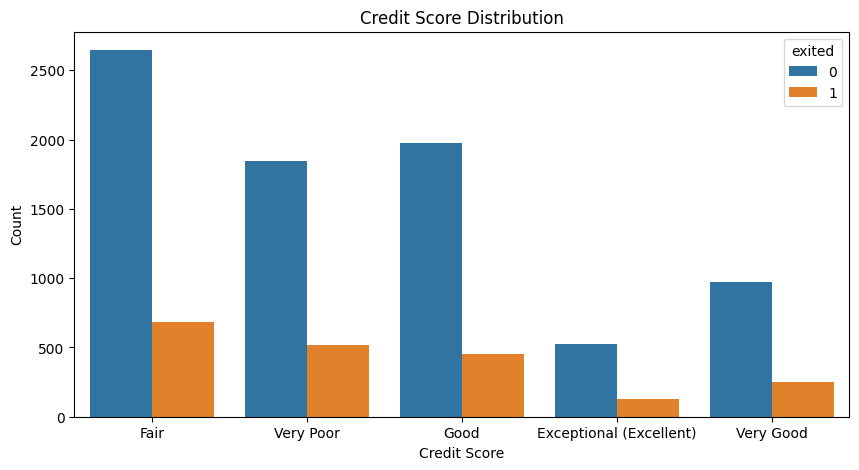

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x = "credit_score_cat", hue = "exited")
plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.show();

In [ ]:
 df.columns

Index(['customerid', 'surname', 'creditscore', 'gender', 'age', 'tenure',
       'balance', 'numofproducts', 'hascrcard', 'isactivemember',
       'estimatedsalary', 'exited', 'state', 'age_group', 'tenure_group',
       'credit_score_cat'],
      dtype='object')

In [ ]:
df["balance"].unique()

array([     0.  ,  83807.86, 159660.8 , ...,  57369.61,  75075.31,
       130142.79])

In [ ]:
df["balance"].min()

0.0

In [ ]:
df["balance"].max()

250898.09

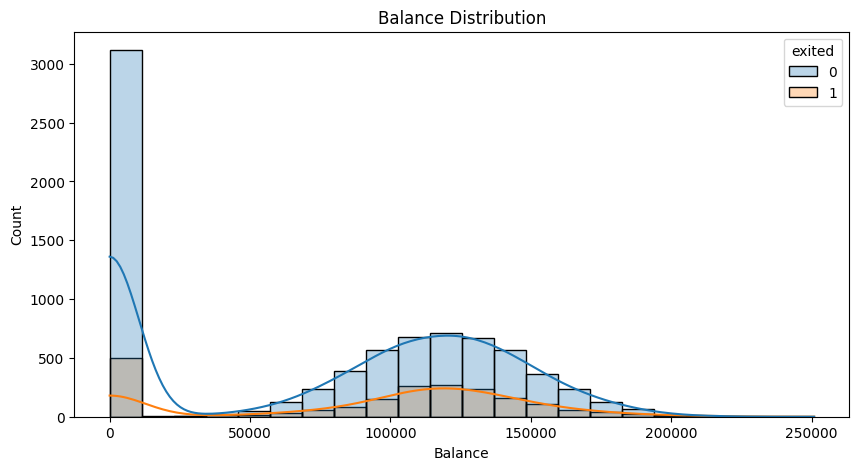

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="balance", kde=True, hue= "exited", alpha = 0.3)
plt.title("Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Count")
plt.show();

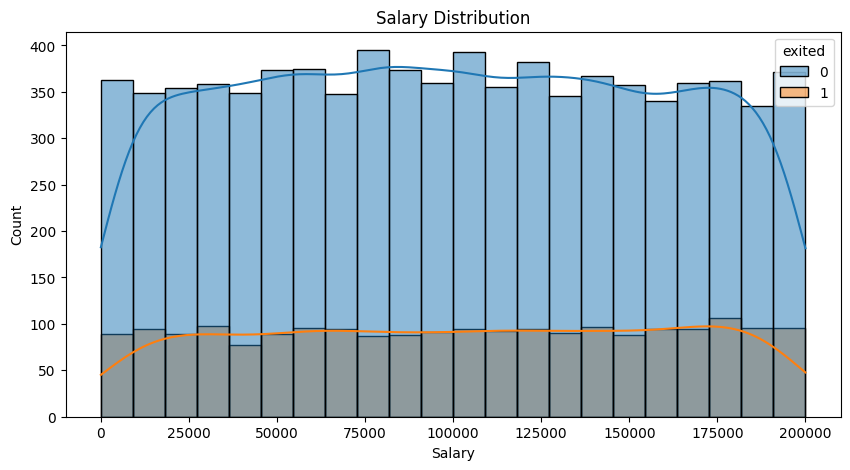

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="estimatedsalary", kde=True, hue= "exited")
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show();

In [ ]:
df.balance.describe()

,balance
count,10000.000000
mean,76485.889288
std,62397.405202
min,0.000000
25%,0.000000
50%,97198.540000
75%,127644.240000
max,250898.090000


In [ ]:
bins = [-0.01, 0, 50000, 100000, 150000, df['balance'].max()]
labels = ['No Balance', 'Low', 'Moderate', 'High', 'Very High']

df['balance_category'] = pd.cut(df['balance'], bins=bins, labels=labels)


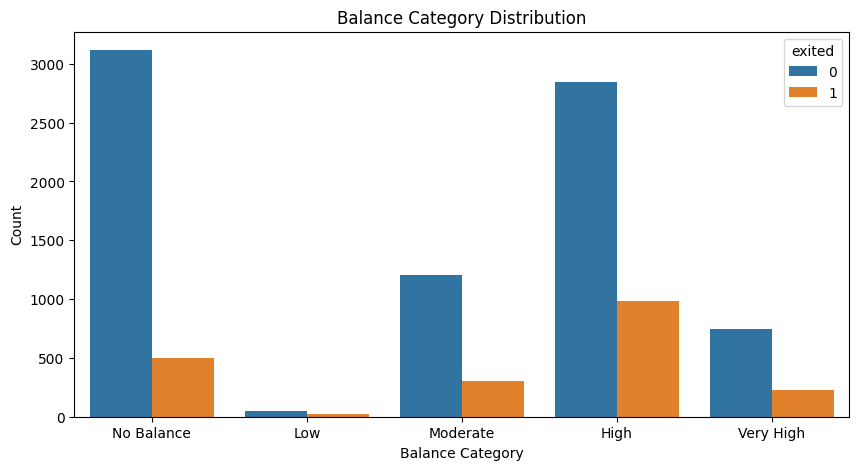

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x = "balance_category", hue = "exited")
plt.title("Balance Category Distribution")
plt.xlabel("Balance Category")
plt.ylabel("Count")
plt.show();


**Notes**:
- More than 25% of the bank customers are either inactive or newly unboarded as they have a balance of 0 usd.
- Customers with balance between 100k to 150k have a high churn rate which should be further investigated


In [ ]:
profile_report = ProfileReport(df)
profile_report.to_file("profile_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 17/17 [00:01<00:00, 15.77it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
df.head()

,customerid,surname,creditscore,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,state,age_group,tenure_group,credit_score_cat,balance_category
0,15634602,Hargrave,619,Female,42,2,0.00,1,1,1,101348.88,1,Virginia,35-44,Early Career,Fair,No Balance
1,15647311,Hill,608,Female,41,1,83807.86,1,0,1,112542.58,0,Texas,35-44,Early Career,Fair,Moderate
2,15619304,Onio,502,Female,42,8,159660.80,3,1,0,113931.57,1,Delaware,35-44,Advanced Experience,Very Poor,Very High
3,15701354,Boni,699,Female,39,1,0.00,2,0,0,93826.63,0,Washington,35-44,Early Career,Good,No Balance
4,15737888,Mitchell,850,Female,43,2,125510.82,1,1,1,79084.10,0,Wisconsin,35-44,Early Career,Exceptional (Excellent),High


In [ ]:
#df.to_csv("cleaned_data.csv")

### **Check Cardinality of columns**

In [ ]:
for i in df.columns:
  print(i, df[i].nunique())

customerid 10000
surname 2932
creditscore 460
gender 2
age 70
tenure 11
balance 6382
numofproducts 4
hascrcard 2
isactivemember 2
estimatedsalary 9999
exited 2
state 50
age_group 6
tenure_group 6
credit_score_cat 5
balance_category 5


In [ ]:
for i in df.select_dtypes(include= 'object').columns:
  print(i, df[i].nunique())

surname 2932
gender 2
state 50
age_group 6
tenure_group 6
credit_score_cat 5


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [ ]:
df.columns

Index(['customerid', 'surname', 'creditscore', 'gender', 'age', 'tenure',
       'balance', 'numofproducts', 'hascrcard', 'isactivemember',
       'estimatedsalary', 'exited', 'state', 'age_group', 'tenure_group',
       'credit_score_cat', 'balance_category'],
      dtype='object')

In [ ]:
state_freq = df['state'].value_counts(normalize=True)
df['state_freq'] = df['state'].map(state_freq)
df = df.drop(columns = ['state', 'surname', 'customerid'], axis=1)

In [ ]:
df.head()

,creditscore,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,age_group,tenure_group,credit_score_cat,balance_category,state_freq
0,619,Female,42,2,0.00,1,1,1,101348.88,1,35-44,Early Career,Fair,No Balance,0.0194
1,608,Female,41,1,83807.86,1,0,1,112542.58,0,35-44,Early Career,Fair,Moderate,0.0202
2,502,Female,42,8,159660.80,3,1,0,113931.57,1,35-44,Advanced Experience,Very Poor,Very High,0.0226
3,699,Female,39,1,0.00,2,0,0,93826.63,0,35-44,Early Career,Good,No Balance,0.0189
4,850,Female,43,2,125510.82,1,1,1,79084.10,0,35-44,Early Career,Exceptional (Excellent),High,0.0212


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   creditscore       10000 non-null  int64   
 1   gender            10000 non-null  object  
 2   age               10000 non-null  int64   
 3   tenure            10000 non-null  int64   
 4   balance           10000 non-null  float64 
 5   numofproducts     10000 non-null  int64   
 6   hascrcard         10000 non-null  int64   
 7   isactivemember    10000 non-null  int64   
 8   estimatedsalary   10000 non-null  float64 
 9   exited            10000 non-null  int64   
 10  age_group         10000 non-null  object  
 11  tenure_group      10000 non-null  object  
 12  credit_score_cat  10000 non-null  object  
 13  balance_category  10000 non-null  category
 14  state_freq        10000 non-null  float64 
dtypes: category(1), float64(3), int64(7), object(4)
memory usage: 1.1+ MB


In [ ]:
df.select_dtypes(include=['object', 'category']).columns.tolist()

['gender', 'age_group', 'tenure_group', 'credit_score_cat', 'balance_category']

In [ ]:
df['exited'].value_counts(normalize=True)

,proportion
exited,
0,0.7963
1,0.2037


### **Target/Feature split**

In [ ]:
target = 'exited'
X = df.drop(columns=[target])
y = df[target]

In [ ]:
categorical_columns = X.select_dtypes(include=['object', 'category']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(X[categorical_columns])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

X_encode = pd.concat([X, one_hot_df], axis=1).drop(columns=categorical_columns, axis = 1)

In [ ]:
X_encode.head()

,creditscore,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,state_freq,gender_Female,...,credit_score_cat_Exceptional (Excellent),credit_score_cat_Fair,credit_score_cat_Good,credit_score_cat_Very Good,credit_score_cat_Very Poor,balance_category_High,balance_category_Low,balance_category_Moderate,balance_category_No Balance,balance_category_Very High
0,619,42,2,0.00,1,1,1,101348.88,0.0194,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,608,41,1,83807.86,1,0,1,112542.58,0.0202,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,502,42,8,159660.80,3,1,0,113931.57,0.0226,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,699,39,1,0.00,2,0,0,93826.63,0.0189,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,850,43,2,125510.82,1,1,1,79084.10,0.0212,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
X_encode.shape

(10000, 33)

### **Train Test Split**

In [ ]:
X_encode.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   creditscore                               10000 non-null  int64  
 1   age                                       10000 non-null  int64  
 2   tenure                                    10000 non-null  int64  
 3   balance                                   10000 non-null  float64
 4   numofproducts                             10000 non-null  int64  
 5   hascrcard                                 10000 non-null  int64  
 6   isactivemember                            10000 non-null  int64  
 7   estimatedsalary                           10000 non-null  float64
 8   state_freq                                10000 non-null  float64
 9   gender_Female                             10000 non-null  float64
 10  gender_Male                        

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encode)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:

# Logistic Regression
lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

# Linear Discriminant Analysis
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)
acc_lda = accuracy_score(y_test, y_pred_lda)

# Decision Tree (CART)
cart = DecisionTreeClassifier(class_weight='balanced', random_state=42)
cart.fit(X_train, y_train)
y_pred_cart = cart.predict(X_test)
acc_cart = accuracy_score(y_test, y_pred_cart)

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)

# Support Vector Machine
svm = SVC(class_weight='balanced', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

# 10. Print Accuracy Scores
print("Model Accuracy Scores:")
print(f"Logistic Regression:      {acc_lr:.3f}")
print(f"LDA:                      {acc_lda:.3f}")
print(f"Decision Tree (CART):     {acc_cart:.3f}")
print(f"Naive Bayes:              {acc_nb:.3f}")
print(f"SVM:                      {acc_svm:.3f}")


Model Accuracy Scores:
Logistic Regression:      0.729
LDA:                      0.820
Decision Tree (CART):     0.779
Naive Bayes:              0.792
SVM:                      0.775


## **Answers to Questions**

**Question 2**: Application of Logistic Regression and Linear Discriminant Analysis (LDA)
To address the supervised learning problem of predicting customer churn (exited), the dataset was first cleaned and prepared. Irrelevant columns such as CustomerId and surname were removed to reduce noise. Categorical variables were handled carefully: the state column was frequency-encoded to avoid a high number of columns resulting from one-hot encoding, while the other categorical features were one-hot encoded. Feature scaling was performed using StandardScaler to normalize the numerical features, a necessary step for algorithms like logistic regression and LDA.

The dataset was then split into training and testing sets using an 80:20 ratio, with the stratify parameter applied to maintain the original class distribution in both sets, this is especially important given the observed class imbalance (approximately 80% of customers stayed and 20% churned).

Logistic Regression was applied with class_weight='balanced' to compensate for the imbalance, ensuring the minority class received appropriate attention during training. Linear Discriminant Analysis (LDA), which does not accept class weights, was applied using default parameters.

Upon evaluation, LDA achieved an accuracy of 82.00%, outperforming Logistic Regression, which reached 72.90%. This indicates that LDA was better at identifying the subtle patterns in the data that distinguish churners from non-churners. Logistic Regression likely underfit the data, struggling to capture the complexity of customer behavior leading to churn.

**Question 3:** Application of CART, Naive Bayes, and Support Vector Machine (SVM)
Building upon the same preprocessed dataset, three additional supervised learning models were implemented: Classification and Regression Trees (CART), Naive Bayes, and Support Vector Machine (SVM). Each model was selected to offer a different approach to classification, from probabilistic modeling to geometric decision boundaries.

CART was trained using class_weight='balanced' to handle class imbalance, similar to Logistic Regression. Naive Bayes and SVM were also trained, with SVM using the balanced class weight approach. The models were evaluated on the same testing set to ensure fair comparison.

The resulting accuracies were as follows:

- Naive Bayes: 79.20%

- CART: 77.9%

- SVM: 77.55%

Naive Bayes performed surprisingly well, likely due to the dataset's compatibility with its assumptions of feature independence. CART showed solid performance but is prone to overfitting without pruning or hyperparameter tuning. SVM, while slightly lower in accuracy, demonstrated good recall for identifying churners, an important metric in retention strategies.

Overall, all three models performed reasonably well, but none exceeded the accuracy achieved by LDA. Each exhibited unique strengths, with Naive Bayes offering simplicity and interpretability, while SVM handled class imbalance effectively with good recall for the minority class.

**Question 4:** Evaluation, Model Selection, and Recommendations
For model evaluation, accuracy was used as the primary performance metric, aligning with the question requirement. However, given the class imbalance in the target variable, additional metrics such as recall and F1-score for the minority class (churned customers) were also reviewed for insight into model fairness and usefulness in a business context.

Among all models tested, Linear Discriminant Analysis (LDA) emerged as the most effective, achieving the highest accuracy of 82.00%. It also provided balanced performance across both classes without requiring additional complexity or tuning. This makes LDA a strong candidate for deployment in a real-world business environment where stability and performance are crucial.

Although SVM demonstrated strong recall on the minority class, it came at the cost of overall accuracy. Logistic Regression underfit the data, performing worst among the tested models. CART and Naive Bayes performed adequately, but not better than LDA.

To further improve model performance, potential enhancements include hyperparameter tuning (e.g., via GridSearchCV for SVM or Decision Trees), incorporating ensemble methods like Random Forest or XGBoost, and exploring more advanced resampling techniques like SMOTE for even better class balancing. Nonetheless, the current LDA model offers a reliable and interpretable solution for predicting churn and supporting customer retention strategies.

## **Visualizing Confusion Matrix**

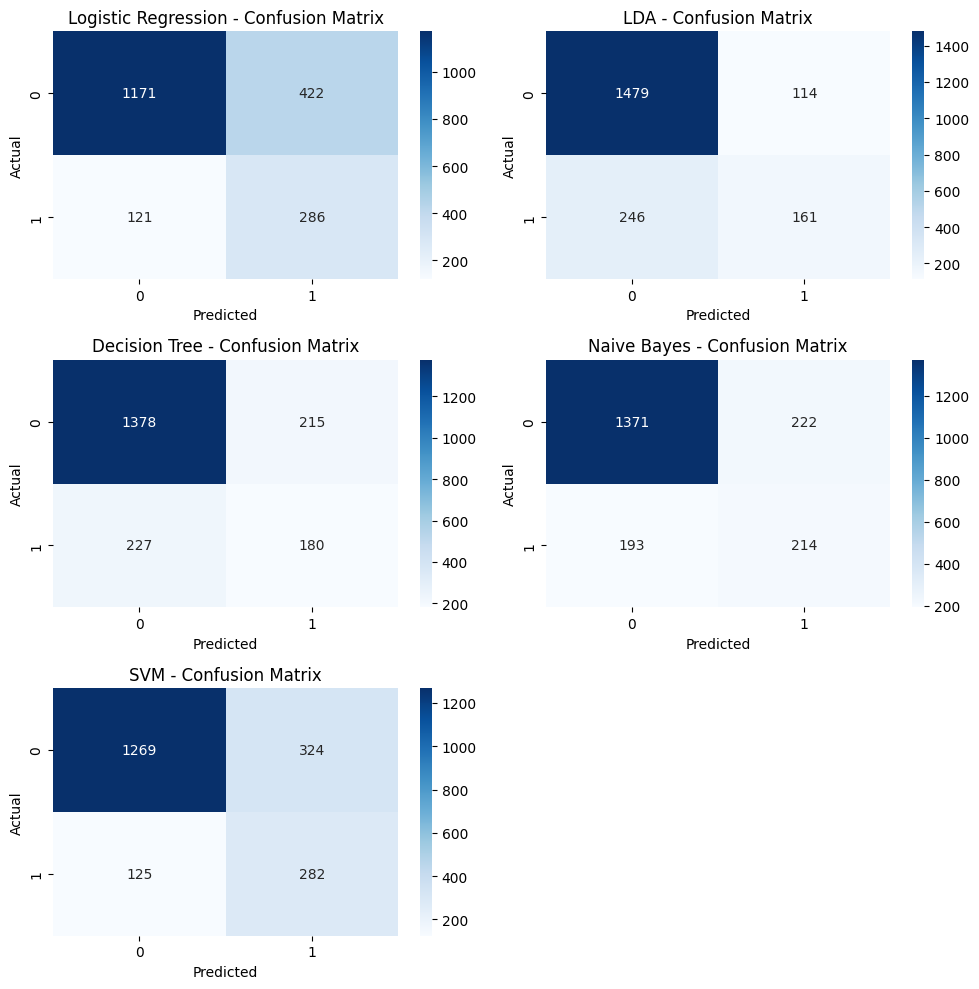

In [ ]:
#Create Confusion Matrix Visualizations
models_predictions = {
    "Logistic Regression": y_pred_lr,
    "LDA": y_pred_lda,
    "Decision Tree": y_pred_cart,
    "Naive Bayes": y_pred_nb,
    "SVM": y_pred_svm
}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10))
axes = axes.flatten()

for i, (model_name, y_pred) in enumerate(models_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i])
    axes[i].set_title(f"{model_name} - Confusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# Remove any unused subplot
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Evaluate and print Accuracy, Recall, F1-score
print(f"{'Model':<22} {'Accuracy':<10} {'Recall':<10} {'F1-score':<10}")
print("-" * 55)

for name, y_pred in models_predictions.items():
    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"{name:<22} {acc:<10.3f} {recall:<10.3f} {f1:<10.3f}")

Model                  Accuracy   Recall     F1-score  
-------------------------------------------------------
Logistic Regression    0.729      0.703      0.513     
LDA                    0.820      0.396      0.472     
Decision Tree          0.779      0.442      0.449     
Naive Bayes            0.792      0.526      0.508     
SVM                    0.775      0.693      0.557     
